In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np

# Model

In [4]:
model = SentenceTransformer('microsoft/biogpt')

No sentence-transformers model found with name microsoft/biogpt. Creating a new one with mean pooling.


# Sentences

In [5]:
##PMID29032535
sentences = \
    ['NP1 buffer supplemented with 1% Triton X-100.'
    , 'NP1 buffer supplemented with 0.1% Triton X-100.',
    'Elution buffer: 0.1 M glycine–HCl, pH 2.5.'
    ,
    '2× SDS sample buffer: 100 mM Tris–HCl, pH 6.8, 4% SDS, 20% glycerol, 5% 2-mercaptoethanol, 2 mM EDTA, 0.1 mg/ mL bromophenol blue'
    ]

In [6]:
sentence_embeddings = model.encode(sentences)

In [7]:
for sentence, embedding in zip(sentences, sentence_embeddings):
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

Sentence: NP1 buffer supplemented with 1% Triton X-100.
Embedding: [-1.4424193   1.831419   -0.6600279  ...  0.14203447  0.60489523
  0.37899604]

Sentence: NP1 buffer supplemented with 0.1% Triton X-100.
Embedding: [-1.5499988   1.8084022  -0.6260594  ...  0.12105974  0.6753263
  0.3069776 ]

Sentence: Elution buffer: 0.1 M glycine–HCl, pH 2.5.
Embedding: [-0.50018847  0.581104   -1.4244474  ... -0.48825198 -0.17164461
 -0.49323565]

Sentence: 2× SDS sample buffer: 100 mM Tris–HCl, pH 6.8, 4% SDS, 20% glycerol, 5% 2-mercaptoethanol, 2 mM EDTA, 0.1 mg/ mL bromophenol blue
Embedding: [-1.6567662   0.9506617  -1.516926   ...  0.4444487   1.1513329
 -0.24039775]



In [8]:
len(sentence_embeddings)

4

In [9]:
len(sentence_embeddings[0])

1024

# Similarity

In [10]:
pprint('Similarity between {} and {} is {}'.format(sentences[0],
       sentences[1],
       cosine_similarity(sentence_embeddings[0].reshape(1, -1),
       sentence_embeddings[1].reshape(1, -1))[0][0]))

('Similarity between NP1 buffer supplemented with 1% Triton X-100. and NP1 '
 'buffer supplemented with 0.1% Triton X-100. is 0.995712399482727')


In [11]:
pprint('Similarity between {} and {} is {}'.format(sentences[0],
       sentences[2],
       cosine_similarity(sentence_embeddings[0].reshape(1, -1),
       sentence_embeddings[2].reshape(1, -1))[0][0]))

('Similarity between NP1 buffer supplemented with 1% Triton X-100. and Elution '
 'buffer: 0.1 M glycine–HCl, pH 2.5. is 0.7240215539932251')


In [12]:
pprint('Similarity between {} and {} is {}'.format(sentences[2],
       sentences[3],
       cosine_similarity(sentence_embeddings[2].reshape(1, -1),
       sentence_embeddings[3].reshape(1, -1))[0][0]))

('Similarity between Elution buffer: 0.1 M glycine–HCl, pH 2.5. and 2× SDS '
 'sample buffer: 100 mM Tris–HCl, pH 6.8, 4% SDS, 20% glycerol, 5% '
 '2-mercaptoethanol, 2 mM EDTA, 0.1 mg/ mL bromophenol blue is '
 '0.8186455368995667')


In [13]:
def lin_viz(vector, sentence):
    bar_width = 0.35
    opacity = 0.8

    fig, ax = plt.subplots()
    
    if vector is np.nan:
        next
    else:
        ax.bar(range(len(vector)), vector, 0.7, alpha=0.9, label=sentence)

    plt.xlabel("", fontsize=16)
    plt.ylabel("Magnitude", fontsize=16)
    plt.legend(loc=0)
    ax.set_ylim([-0.22,0.22])
    plt.show;

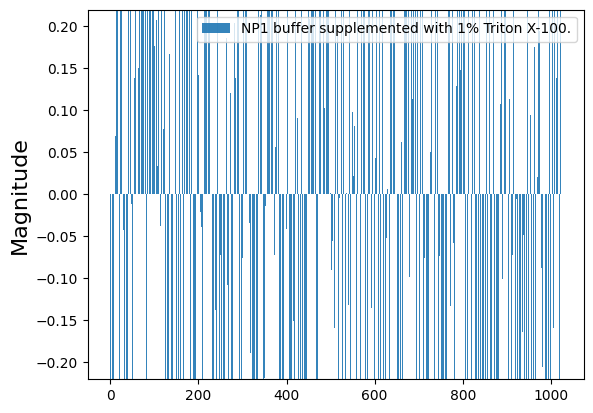

In [19]:
lin_viz(sentence_embeddings[0],sentences[0])